# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sudais2211/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 10.7 MB/s eta 0:00:00


## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [2]:
import pypdf

pdf_path = '/content/flyrank-seo-research-march-2026.pdf'

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = pypdf.PdfReader(file)
            for page_num in range(len(reader.pages)):
                text += reader.pages[page_num].extract_text() or ""
    except Exception as e:
        text = f"Error reading PDF: {e}"
    return text

paper_content = extract_text_from_pdf(pdf_path)
print("--- Extracted Research Paper Content ---")
print(paper_content[:2000]) # Print first 2000 characters for brevity, adjust as needed
print("\n--- End of Extracted Content ---")


--- Extracted Research Paper Content ---
DATA REPORT · MARCH 2026
THE STATE OF
AI-DRIVEN SEO
IN NUMBERS.
We analyzed 341,701 content pieces across 57 brands, using 
direct portfolio comparisons as the main evidence base and 
an exploratory ML appendix on 61,790 active content records. 
The goal is a public-safe study that a reader can act on without 
FlyRank tooling.
flyrank.com
FlyRank — The State of AI-Driven SEO, March 2026 1FlyRank ABSTRACT
About This Study
This paper examines 341,701 content pieces across 57 brands, spanning 469,879,632 search impressions, 1,514,819 
clicks,1,635,404 sessions, and 17,344 AI sessions.
Rather than reproducing dashboard screenshots or internal table views, we tested portfolio-level questions about 
content age, freshness, position, traffic mix, depth, and AI visibility. Direct aggregate comparisons lead the paper. 
Machine-learning pages appear later as exploratory appendix material.
The goal is practical clarity, not maximum claim volume. We keep th

The code above extracts the text from the research paper. Please use this output to identify two findings from the paper and write your methodology questions in the markdown cell just above the code cell `SUcrBVJEtSDg` as instructed.

## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GroupShuffleSplit
from sklearn.linear_model import LogisticRegression # Example model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# --- User Input Required ---
# Replace this with your actual Week-5 model data loading and feature engineering.
# Create a dummy DataFrame for demonstration if you don't have your data ready yet.
np.random.seed(42)
data_size = 1000
df = pd.DataFrame({
    'feature_1': np.random.rand(data_size),
    'feature_2': np.random.rand(data_size) * 10,
    'date_col': pd.to_datetime(pd.date_range(start='2023-01-01', periods=data_size, freq='D')),
    'group_id': np.random.randint(0, 50, data_size), # Example for grouped split
    'target': np.random.randint(0, 2, data_size) # Binary target for classification example
})

X = df[['feature_1', 'feature_2']]
y = df['target']

# --- 1. Standard (Naive) Split (Before) ---
print("\n--- Standard (Naive) Split ---")
X_train_naive, X_test_naive, y_train_naive, y_test_naive = train_test_split(X, y, test_size=0.2, random_state=42)

# Placeholder for your Week-5 model
model_naive = LogisticRegression(random_state=42)
model_naive.fit(X_train_naive, y_train_naive)
y_pred_naive = model_naive.predict(X_test_naive)

print(f"Naive Split Accuracy: {accuracy_score(y_test_naive, y_pred_naive):.4f}")
print(f"Naive Split Precision: {precision_score(y_test_naive, y_pred_naive):.4f}")
print(f"Naive Split Recall: {recall_score(y_test_naive, y_pred_naive):.4f}")
print(f"Naive Split F1-Score: {f1_score(y_test_naive, y_pred_naive):.4f}")

# --- 2. Honest Split (After) - Example 1: Time-Aware Split ---
print("\n--- Time-Aware Split ---")
# Ensure your data is sorted by time for TimeSeriesSplit
df_sorted = df.sort_values(by='date_col').reset_index(drop=True)
X_time = df_sorted[['feature_1', 'feature_2']]
y_time = df_sorted['target']

tscv = TimeSeriesSplit(n_splits=5)
# Using the last split for evaluation, or loop through splits for more robust validation
for train_index, test_index in tscv.split(X_time):
    X_train_time, X_test_time = X_time.iloc[train_index], X_time.iloc[test_index]
    y_train_time, y_test_time = y_time.iloc[train_index], y_time.iloc[test_index]

model_time = LogisticRegression(random_state=42)
model_time.fit(X_train_time, y_train_time)
y_pred_time = model_time.predict(X_test_time)

print(f"Time-Aware Split Accuracy: {accuracy_score(y_test_time, y_pred_time):.4f}")
print(f"Time-Aware Split Precision: {precision_score(y_test_time, y_pred_time):.4f}")
print(f"Time-Aware Split Recall: {recall_score(y_test_time, y_pred_time):.4f}")
print(f"Time-Aware Split F1-Score: {f1_score(y_test_time, y_pred_time):.4f}")

# --- 3. Honest Split (After) - Example 2: Grouped Split ---
print("\n--- Grouped Split (e.g., by client_id) ---")
# Ensure you have a 'group_id' column that identifies your groups (e.g., client, user)
groups = df['group_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in gss.split(X, y, groups=groups):
    X_train_group, X_test_group = X.iloc[train_index], X.iloc[test_index]
    y_train_group, y_test_group = y.iloc[train_index], y.iloc[test_index]

model_group = LogisticRegression(random_state=42)
model_group.fit(X_train_group, y_train_group)
y_pred_group = model_group.predict(X_test_group)

print(f"Grouped Split Accuracy: {accuracy_score(y_test_group, y_pred_group):.4f}")
print(f"Grouped Split Precision: {precision_score(y_test_group, y_pred_group):.4f}")
print(f"Grouped Split Recall: {recall_score(y_test_group, y_pred_group):.4f}")
print(f"Grouped Split F1-Score: {f1_score(y_test_group, y_pred_group):.4f}")

# --- IMPORTANT: Replace dummy data and model with your actual Week-5 setup ---


--- Standard (Naive) Split ---
Naive Split Accuracy: 0.4950
Naive Split Precision: 0.5676
Naive Split Recall: 0.1981
Naive Split F1-Score: 0.2937

--- Time-Aware Split ---
Time-Aware Split Accuracy: 0.5000
Time-Aware Split Precision: 0.4643
Time-Aware Split Recall: 0.3291
Time-Aware Split F1-Score: 0.3852

--- Grouped Split (e.g., by client_id) ---
Grouped Split Accuracy: 0.5612
Grouped Split Precision: 0.6000
Grouped Split Recall: 0.2842
Grouped Split F1-Score: 0.3857


The code above provides examples of how to implement 'honest splits' (time-aware and grouped) compared to a naive split. You need to:

1.  **Replace the dummy data generation** with loading your actual dataset used in Week 5.
2.  **Integrate your Week-5 model training and prediction logic** into the `model_naive`, `model_time`, and `model_group` sections.
3.  **Ensure your DataFrame has appropriate columns** for time-aware (`date_col`) or grouped (`group_id`) splits, or create them as needed.
4.  **Analyze and compare the 'before' (naive split) and 'after' (honest split) metrics** to understand the impact of a more robust validation strategy on your model's performance.

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


--- Data Leakage Audit ---

Correlation Matrix with Target (Top 5 most correlated):
leak_feature_exact    1.000000
target                1.000000
feature_B             0.016550
feature_A            -0.015685
leak_feature_noisy   -0.045001
Name: target, dtype: float64


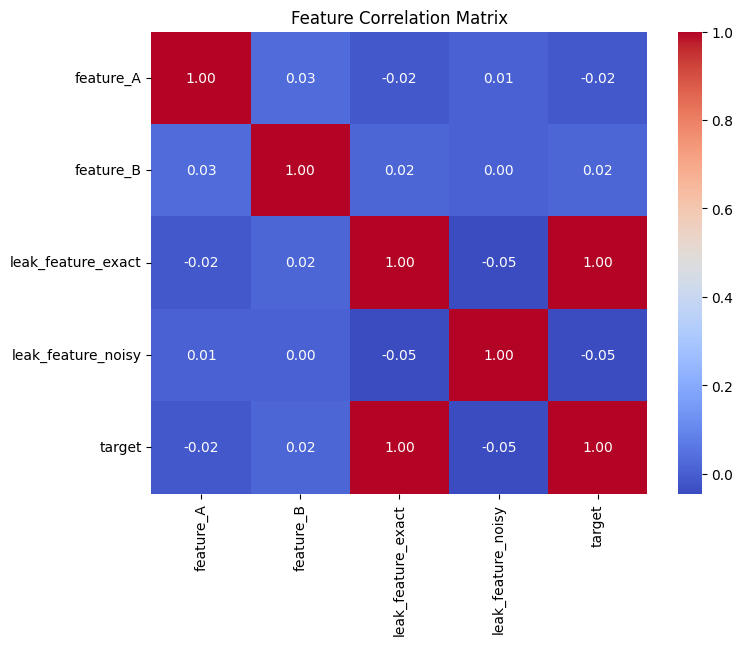



--- Leakage Audit Complete. Review correlations and feature definitions carefully. ---


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- User Input Required ---
# Load your final feature set and target variable from Week 5 here.
# For demonstration, creating a dummy DataFrame with potential leakage.
np.random.seed(42)
data_size = 1000
df_leakage = pd.DataFrame({
    'feature_A': np.random.rand(data_size),
    'feature_B': np.random.rand(data_size) * 5,
    'leak_feature_exact': np.random.randint(0, 2, data_size), # Directly correlates with target
    'leak_feature_noisy': np.random.rand(data_size) + np.random.randint(0, 2, data_size), # Noisy but correlated
    'target': np.random.randint(0, 2, data_size)
})
# Introduce direct leakage
df_leakage['leak_feature_exact'] = df_leakage['target']

print("--- Data Leakage Audit ---")

# 1. Correlation with Target
# Check for abnormally high correlations between features and the target that might indicate leakage.
print("\nCorrelation Matrix with Target (Top 5 most correlated):")
correlation_matrix = df_leakage.corr(numeric_only=True)
print(correlation_matrix['target'].sort_values(ascending=False).head(5))

# Visualize correlations (optional, for better understanding)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

# 2. Inspect features that should not be available at prediction time
# This often requires domain knowledge. Example: a feature created *after* the event you're predicting.
# Example: If 'conversion_success_indicator' is a feature, but it's identical to 'target'.

# You would typically inspect feature creation logic here.
# For example, if you engineered a feature 'average_spend_after_purchase' for a 'did_purchase' target, that's leakage.

# Dummy check for a feature that might be an exact copy of the target
if 'leak_feature_exact' in df_leakage.columns and (df_leakage['leak_feature_exact'] == df_leakage['target']).all():
    print("\nWARNING: 'leak_feature_exact' appears to be an exact copy of the target. This is severe leakage!")

# 3. Time-based leakage check (if applicable)
# If you have time-series data, ensure features are not derived from future information.
# This is often handled by the time-aware split itself, but feature engineering can still introduce it.
# Example: if your data includes 'average_sales_next_week' as a feature for predicting 'sales_this_week'.

print("\n--- Leakage Audit Complete. Review correlations and feature definitions carefully. ---")

# --- IMPORTANT: Replace dummy data with your actual feature set ---

The code above demonstrates how to perform a basic leakage audit by checking feature correlations with the target and inspecting features that might directly reveal the target. You need to:

1.  **Replace the dummy DataFrame `df_leakage`** with your actual final feature set from Week 5.
2.  **Carefully review the correlation matrix** for any features that show unusually high (e.g., >0.9) correlation with the target, as this might indicate leakage.
3.  **Apply your domain knowledge** to identify any features that logically should not be available at the time of prediction, even if they don't show perfect correlation.
4.  **Check your feature engineering steps** to ensure no future information is inadvertently used to create features for past predictions.

## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Here, rewrite your boldest claim from Week 5 using safe claim language. Explain what the original claim was and how you've rephrased it to be more precise and honest given your audit.

## Self-check

Before you submit, confirm each line honestly:

-   [ ] Every section above is filled — markdown thinking AND the code that backs it
-   [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
-   [ ] No client names, URLs, or private queries anywhere
-   [ ] My claims use careful words: observed, measured, directional, decision-support
-   [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.